Distribution of Dominant MI Types:
Dominant_MI
Intrapersonal    50
Interpersonal    35
Musical          27
Kinesthetic      24
Logical          21
Verbal           19
Existential      18
Naturalist       14
Visual            6
Name: count, dtype: int64

Confidence Change Distribution:
Confidence Change
-3     7
-2    18
-1    62
 0    82
 1    37
 2     6
 3     2
Name: count, dtype: int64


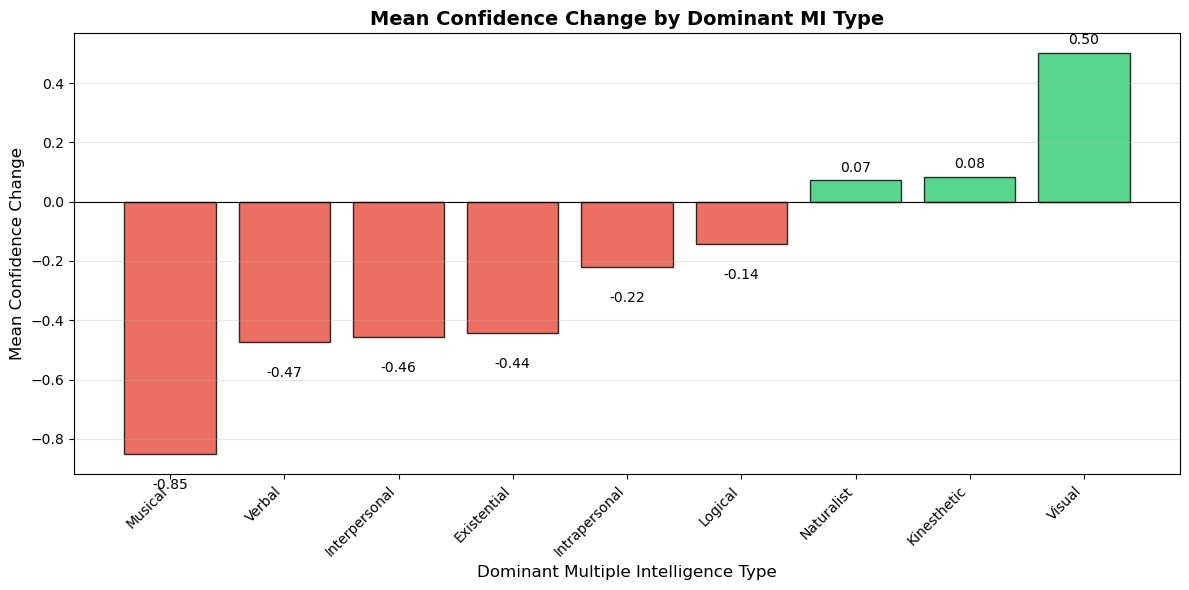


Plot 1 saved: confidence_change_mean_bar.png


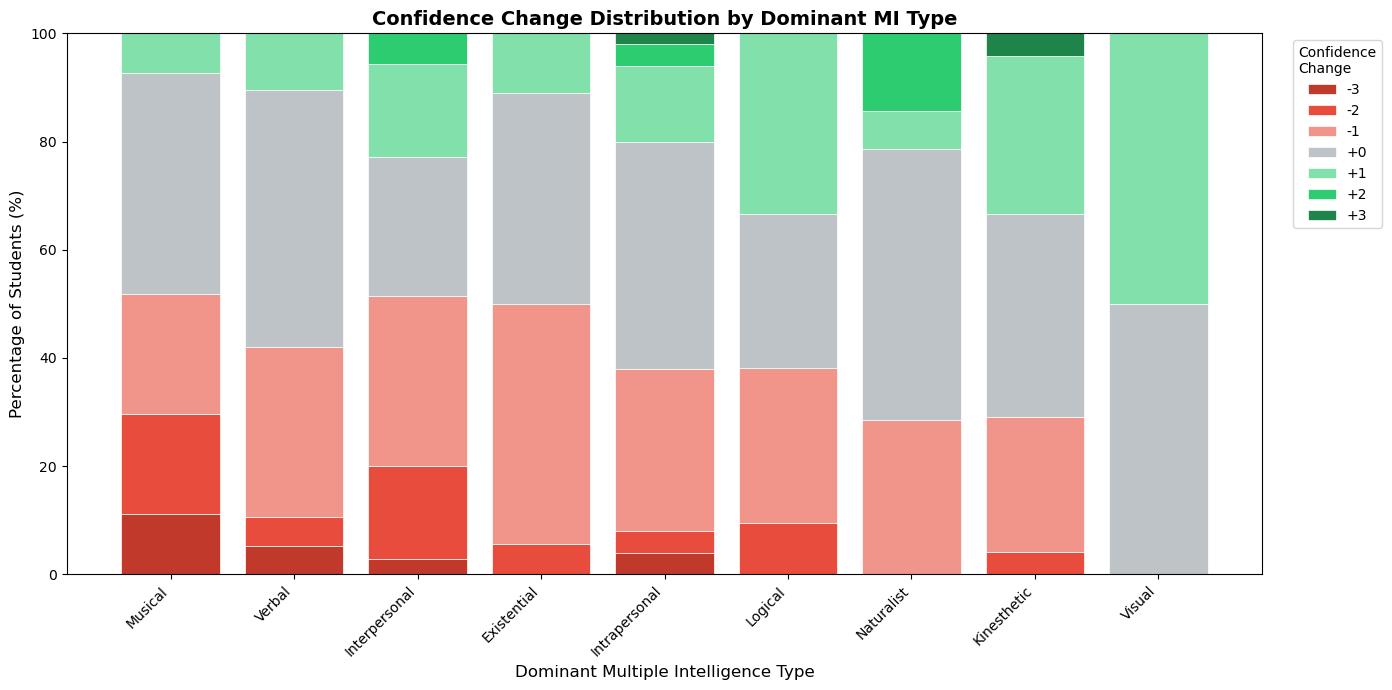

Plot 2 saved: confidence_change_distribution_bar.png


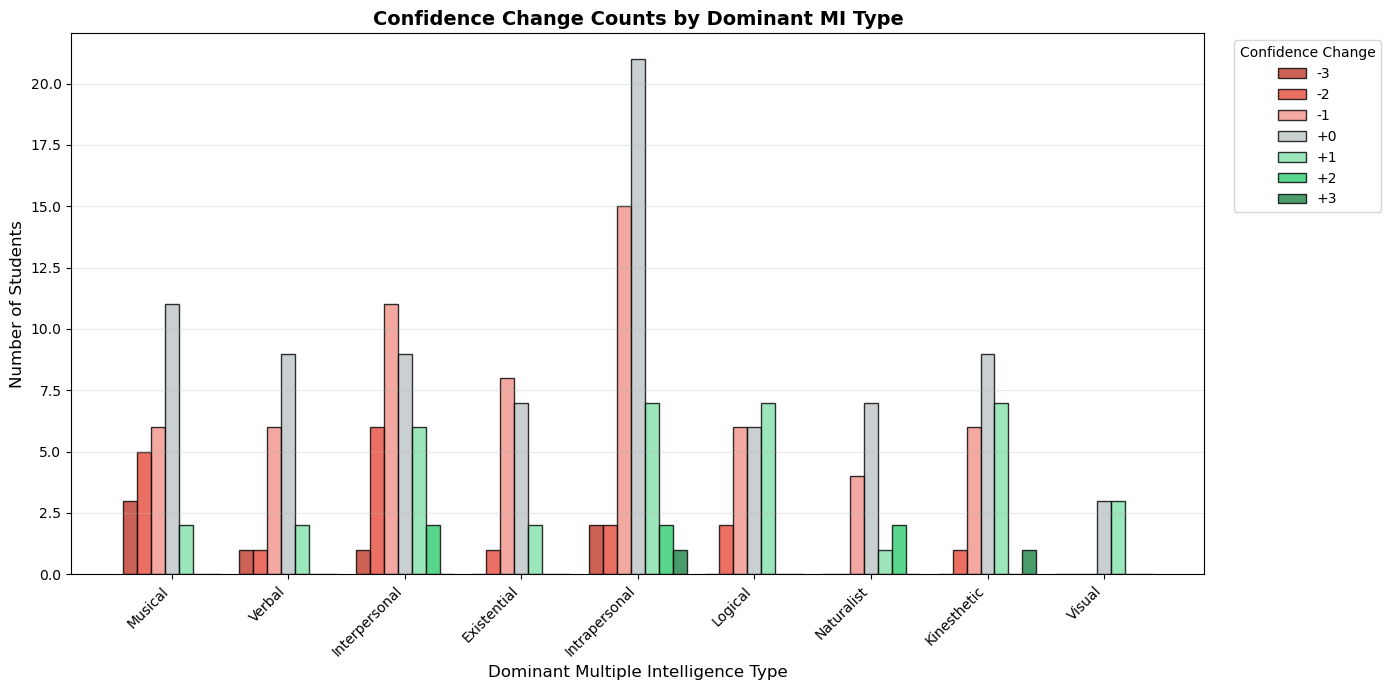

Plot 3 saved: confidence_change_counts_bar.png

Summary: Confidence Change by Dominant MI Type
                Mean  Std Dev  Count
Dominant_MI                         
Musical       -0.852    1.167     27
Verbal        -0.474    0.964     19
Interpersonal -0.457    1.221     35
Existential   -0.444    0.784     18
Intrapersonal -0.220    1.130     50
Logical       -0.143    1.014     21
Naturalist     0.071    0.997     14
Kinesthetic    0.083    1.060     24
Visual         0.500    0.548      6


In [3]:
"""
Multiple Intelligence vs Confidence Change Bar Graph Analysis
Using generated sample data similar to actual MI survey results
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

n_students = 214

mi_types = ['Naturalist', 'Musical', 'Logical', 'Existential', 
            'Interpersonal', 'Kinesthetic', 'Verbal', 'Intrapersonal', 'Visual']

data = {'Students': range(1, n_students + 1)}

# Generate MI scores with different means to create varied dominant types
mi_means = {
    'Naturalist': 4.4, 'Musical': 5.1, 'Logical': 4.8, 'Existential': 5.0,
    'Interpersonal': 5.2, 'Kinesthetic': 5.3, 'Verbal': 4.5, 
    'Intrapersonal': 6.6, 'Visual': 4.8
}

for mi in mi_types:
    scores = np.random.normal(mi_means[mi], 2, n_students)
    data[mi] = np.clip(scores, 0, 10).round()

df = pd.DataFrame(data)
df['Dominant_MI'] = df[mi_types].idxmax(axis=1)

# Generate Confidence Change data (-3 to +3) with realistic distribution
# Most students show slight decrease or no change
confidence_probs = {
    -3: 0.04,   # 4% show large decrease
    -2: 0.07,   # 7% moderate decrease
    -1: 0.31,   # 31% slight decrease
     0: 0.38,   # 38% no change
     1: 0.16,   # 16% slight increase
     2: 0.03,   # 3% moderate increase
     3: 0.01    # 1% large increase
}

confidence_values = list(confidence_probs.keys())
confidence_weights = list(confidence_probs.values())

df['Confidence Change'] = np.random.choice(
    confidence_values, 
    size=n_students, 
    p=confidence_weights
)

# Print data summary
print("Distribution of Dominant MI Types:")
print(df['Dominant_MI'].value_counts().sort_values(ascending=False))
print("\nConfidence Change Distribution:")
print(df['Confidence Change'].value_counts().sort_index())

# ============================================================
# PLOT 1: Mean Confidence Change by MI Type (Bar Graph)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

mean_confidence = df.groupby('Dominant_MI')['Confidence Change'].mean().sort_values()

colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in mean_confidence.values]

bars = ax.bar(range(len(mean_confidence)), mean_confidence.values, color=colors, edgecolor='black', alpha=0.8)

ax.set_xticks(range(len(mean_confidence)))
ax.set_xticklabels(mean_confidence.index, rotation=45, ha='right')
ax.set_xlabel('Dominant Multiple Intelligence Type', fontsize=12)
ax.set_ylabel('Mean Confidence Change', fontsize=12)
ax.set_title('Mean Confidence Change by Dominant MI Type', fontsize=14, fontweight='bold')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, mean_confidence.values):
    ypos = val + 0.02 if val >= 0 else val - 0.08
    ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{val:.2f}', 
            ha='center', va='bottom' if val >= 0 else 'top', fontsize=10)

plt.tight_layout()
plt.savefig('confidence_change_mean_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot 1 saved: confidence_change_mean_bar.png")

# ============================================================
# PLOT 2: Stacked Bar - Confidence Change Distribution by MI Type
# ============================================================
fig, ax = plt.subplots(figsize=(14, 7))

# Create crosstab of MI type vs confidence change
crosstab = pd.crosstab(df['Dominant_MI'], df['Confidence Change'], normalize='index') * 100

# Sort by mean confidence change
mi_order = df.groupby('Dominant_MI')['Confidence Change'].mean().sort_values().index
crosstab = crosstab.reindex(mi_order)

# Color map: red for negative, gray for 0, green for positive
change_colors = {
    -3: '#c0392b',  # dark red
    -2: '#e74c3c',  # red
    -1: '#f1948a',  # light red
     0: '#bdc3c7',  # gray
     1: '#82e0aa',  # light green
     2: '#2ecc71',  # green
     3: '#1e8449'   # dark green
}

# Plot stacked bars
bottom = np.zeros(len(crosstab))
for change_val in sorted(crosstab.columns):
    if change_val in crosstab.columns:
        values = crosstab[change_val].values
        ax.bar(range(len(crosstab)), values, bottom=bottom, 
               label=f'{change_val:+d}', color=change_colors.get(change_val, '#95a5a6'),
               edgecolor='white', linewidth=0.5)
        bottom += values

ax.set_xticks(range(len(crosstab)))
ax.set_xticklabels(crosstab.index, rotation=45, ha='right')
ax.set_xlabel('Dominant Multiple Intelligence Type', fontsize=12)
ax.set_ylabel('Percentage of Students (%)', fontsize=12)
ax.set_title('Confidence Change Distribution by Dominant MI Type', fontsize=14, fontweight='bold')
ax.legend(title='Confidence\nChange', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('confidence_change_distribution_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot 2 saved: confidence_change_distribution_bar.png")

# ============================================================
# PLOT 3: Grouped Bar - Count of Each Confidence Level by MI Type
# ============================================================
fig, ax = plt.subplots(figsize=(14, 7))

crosstab_counts = pd.crosstab(df['Dominant_MI'], df['Confidence Change'])
crosstab_counts = crosstab_counts.reindex(mi_order)

x = np.arange(len(crosstab_counts))
width = 0.12
multiplier = 0

for change_val in sorted(crosstab_counts.columns):
    offset = width * multiplier
    values = crosstab_counts[change_val].values
    bars = ax.bar(x + offset, values, width, label=f'{change_val:+d}', 
                  color=change_colors.get(change_val, '#95a5a6'), edgecolor='black', alpha=0.8)
    multiplier += 1

ax.set_xticks(x + width * 3)
ax.set_xticklabels(crosstab_counts.index, rotation=45, ha='right')
ax.set_xlabel('Dominant Multiple Intelligence Type', fontsize=12)
ax.set_ylabel('Number of Students', fontsize=12)
ax.set_title('Confidence Change Counts by Dominant MI Type', fontsize=14, fontweight='bold')
ax.legend(title='Confidence Change', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('confidence_change_counts_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot 3 saved: confidence_change_counts_bar.png")

# ============================================================
# Summary Statistics
# ============================================================
print("\n" + "="*60)
print("Summary: Confidence Change by Dominant MI Type")
print("="*60)
summary = df.groupby('Dominant_MI')['Confidence Change'].agg(['mean', 'std', 'count']).round(3)
summary.columns = ['Mean', 'Std Dev', 'Count']
print(summary.sort_values('Mean'))